In [18]:
import os
import glob
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
from scipy.stats import skew

In [19]:
DATA_FOLDER = "/content/MI_extracted/MI/MI CSV"
LABELS_PATH = "/content/labels.csv"

labels_df = pd.read_csv(LABELS_PATH)
eeg_files = glob.glob(os.path.join(DATA_FOLDER, "*.csv"))

def extract_number(path):
    match = re.search(r'(\d+)\.csv$', os.path.basename(path))
    return int(match.group(1)) if match else None

file_map = {extract_number(f): f for f in eeg_files}

matched_rows = []
for idx in range(len(labels_df)):
    csv_number = idx + 1
    if csv_number in file_map:
        matched_rows.append({
            "trial_id": csv_number,
            "file_path": file_map[csv_number],
            "label": labels_df.iloc[idx]["label"]
        })

matched_df = pd.DataFrame(matched_rows)

all_numbers = set(file_map.keys())
matched_numbers = set(matched_df["trial_id"])
skipped_no_label = len(all_numbers - matched_numbers)

print("Matched trials:", len(matched_df))
print("Files with no label:", len(labels_df) - len(matched_rows) - skipped_no_label)
print("Labels with no file:", skipped_no_label)

Matched trials: 2160
Files with no label: 240
Labels with no file: 0


In [20]:
eda_records = []
file_hashes = {}
duplicate_files = []

for _, row in matched_df.iterrows():
    df = pd.read_csv(row["file_path"])

    file_hash = pd.util.hash_pandas_object(df).sum()
    if file_hash in file_hashes:
        duplicate_files.append((row["file_path"], file_hashes[file_hash]))
    else:
        file_hashes[file_hash] = row["file_path"]

    record = {"trial_id": row["trial_id"], "n_rows": len(df), "n_nulls": df.isnull().sum().sum()}
    for ch in ["FZ", "C3", "CZ", "C4"]:
        record[f"{ch}_skew"] = skew(df[ch])
    eda_records.append(record)

eda_df = pd.DataFrame(eda_records)

print("Row count consistency:\n", eda_df["n_rows"].value_counts())
print("\nTotal nulls:", eda_df["n_nulls"].sum())
print("Duplicate files found:", len(duplicate_files))
print("\nSkew per channel (mean):\n", eda_df[[c for c in eda_df.columns if "skew" in c]].mean())

Row count consistency:
 n_rows
2500    2160
Name: count, dtype: int64

Total nulls: 0
Duplicate files found: 36

Skew per channel (mean):
 FZ_skew    0.041905
C3_skew    0.023659
CZ_skew    0.008610
C4_skew    0.018228
dtype: float64


In [21]:
duplicate_paths = set(f[0] for f in duplicate_files)
matched_df = matched_df[~matched_df["file_path"].isin(duplicate_paths)].reset_index(drop=True)
print("Trials after removing duplicates:", len(matched_df))

Trials after removing duplicates: 2124


In [22]:
sample_df = pd.read_csv(matched_df.iloc[0]["file_path"])
fs = 1 / sample_df["Time"].diff().dropna().mean()
print("Sampling frequency:", fs)

channels = ["FZ", "C3", "CZ", "C4"]

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    b, a = butter(order, [lowcut / nyquist, highcut / nyquist], btype="band")
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, q=30):
    b, a = iirnotch(notch_freq, q, fs)
    return filtfilt(b, a, data)

def preprocess_trial(df, fs):
    processed = df.copy()
    for ch in channels:
        processed[ch] = bandpass_filter(processed[ch], 0.5, 40, fs)
    for ch in channels:
        processed[ch] = notch_filter(processed[ch], 50, fs)
    reference = processed[channels].mean(axis=1)
    for ch in channels:
        processed[ch] = processed[ch] - reference
    return processed

Sampling frequency: 250.02385931937627


In [23]:
def is_artifact(df, channels, z_thresh=6):
    for ch in channels:
        median = df[ch].median()
        mad = (df[ch] - median).abs().median() * 1.4826
        if mad == 0:
            continue
        z = (df[ch] - median) / mad
        if (z.abs() > z_thresh).any():
            return True
    return False

processed_trials = []
processed_labels = []
processed_trial_ids = []
rejected_log = []

for _, row in matched_df.iterrows():
    trial_df = pd.read_csv(row["file_path"])

    if is_artifact(trial_df, channels):
        rejected_log.append(row["trial_id"])
        continue

    processed_df = preprocess_trial(trial_df, fs)
    processed_trials.append(processed_df)
    processed_labels.append(row["label"])
    processed_trial_ids.append(row["trial_id"])

print("Kept trials:", len(processed_trials))
print("Rejected trials (artifact):", len(rejected_log))
print("Rejection rate: {:.1f}%".format(100 * len(rejected_log) / len(matched_df)))

Kept trials: 2049
Rejected trials (artifact): 75
Rejection rate: 3.5%


In [24]:
epoch_length = int(2 * fs)

def create_epochs(df, epoch_length):
    return [df.iloc[start:start+epoch_length].copy()
            for start in range(0, len(df) - epoch_length + 1, epoch_length)]

def baseline_correction(epoch):
    corrected = epoch.copy()
    for ch in channels:
        corrected[ch] = corrected[ch] - corrected[ch].mean()
    return corrected

all_epochs, all_epoch_labels, all_epoch_trial_ids = [], [], []

for trial, label, tid in zip(processed_trials, processed_labels, processed_trial_ids):
    trial_epochs = [baseline_correction(e) for e in create_epochs(trial, epoch_length)]
    all_epochs.extend(trial_epochs)
    all_epoch_labels.extend([label] * len(trial_epochs))
    all_epoch_trial_ids.extend([tid] * len(trial_epochs))

print("Total epochs:", len(all_epochs))

Total epochs: 10245


In [30]:
def epoch_is_artifact(epoch, channels, z_thresh=6):
    for ch in channels:
        median = epoch[ch].median()
        mad = (epoch[ch] - median).abs().median() * 1.4826
        if mad == 0:
            continue
        z = (epoch[ch] - median) / mad
        if (z.abs() > z_thresh).any():
            return True
    return False

clean_epochs, clean_labels, clean_trial_ids = [], [], []
epoch_rejected = 0

for e, l, t in zip(all_epochs, all_epoch_labels, all_epoch_trial_ids):
    if epoch_is_artifact(e, channels):
        epoch_rejected += 1
        continue
    clean_epochs.append(e)
    clean_labels.append(l)
    clean_trial_ids.append(t)

print("Epochs before:", len(all_epochs))
print("Epochs rejected (epoch-level artifact):", epoch_rejected)
print("Epochs kept:", len(clean_epochs))

all_epochs, all_epoch_labels, all_epoch_trial_ids = clean_epochs, clean_labels, clean_trial_ids

Epochs before: 10245
Epochs rejected (epoch-level artifact): 5155
Epochs kept: 5090


In [31]:
processed_dataset = {
    "epochs": all_epochs,
    "epoch_labels": all_epoch_labels,
    "epoch_trial_ids": all_epoch_trial_ids,
    "rejected_trials": rejected_log,
    "eda_summary": eda_df
}

with open("/content/processed_eeg_dataset.pkl", "wb") as f:
    pickle.dump(processed_dataset, f)

print("Saved. Epochs:", len(all_epochs))
print("Unique trials represented:", len(set(all_epoch_trial_ids)))

Saved. Epochs: 5090
Unique trials represented: 1957


Post preprocessing EDA

In [27]:
for ax, ch in zip(axes, ["C3", "C4"]):
    ...
    ax.set_ylim(0, 5000)  # cut off the low-freq spike so mu/beta is visible

=== Epoch class balance ===
Left     2552
Right    2538
Name: count, dtype: int64
Balance ratio: 0.99

=== Trial-level summary ===
Trials kept after artifact rejection: 2049
Trials rejected: 75
Unique trials in epochs: 1957
Epochs per trial (mean): 2.6009197751660706

=== Post-filter amplitude stats (should be centered near 0, small scale) ===
                 FZ            C3            CZ            C4
count  1.000000e+05  1.000000e+05  1.000000e+05  1.000000e+05
mean  -7.730705e-17  3.410605e-18 -1.318767e-16 -3.410605e-17
std    3.342802e+01  2.923338e+01  3.099294e+01  5.060991e+01
min   -6.727019e+02 -4.905866e+02 -6.873476e+02 -1.366092e+03
25%   -6.628623e+00 -6.221444e+00 -4.058364e+00 -7.187041e+00
50%   -4.402762e-02  1.446583e-01 -2.316631e-02  6.693427e-02
75%    6.809300e+00  6.665276e+00  3.888967e+00  7.212480e+00
max    5.105273e+02  6.412700e+02  7.483313e+02  7.298617e+02


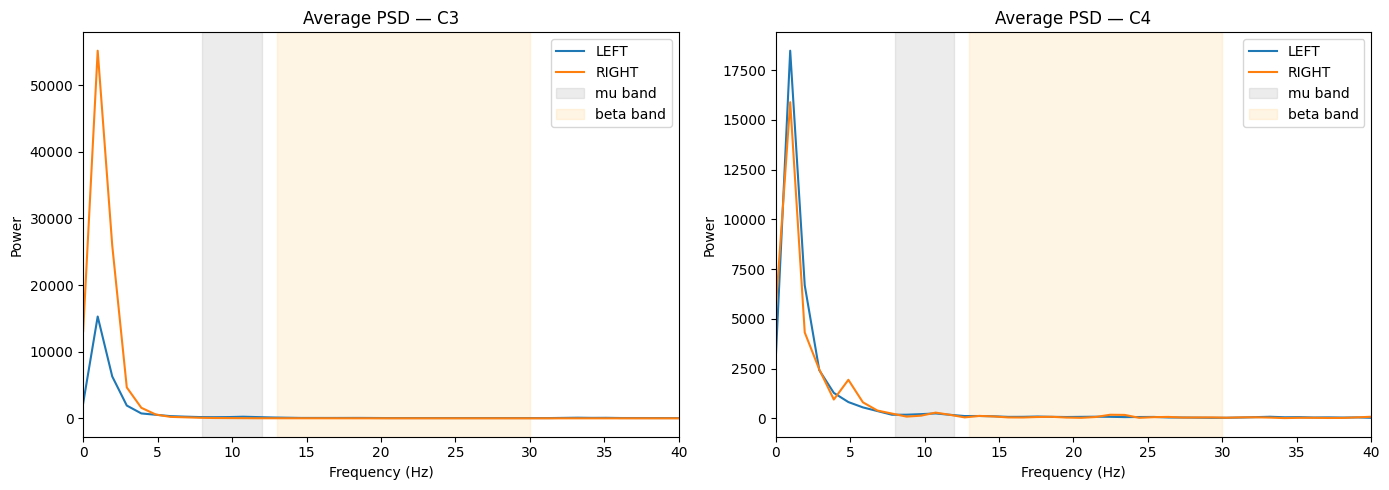

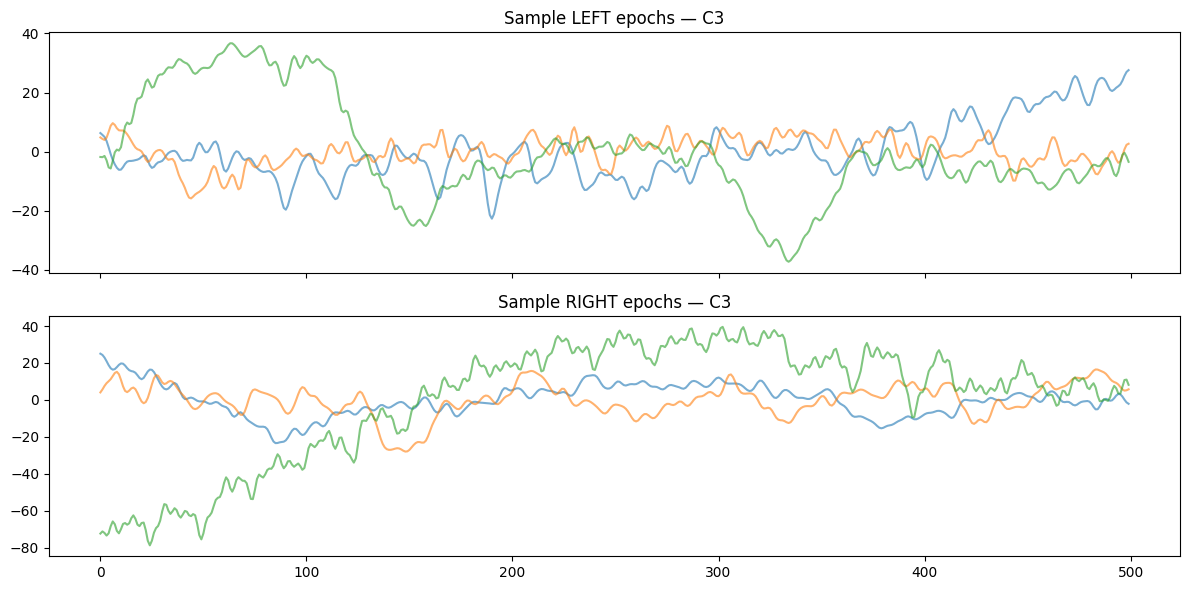

In [32]:
from scipy.signal import welch

# 1. Class balance after all rejections
epoch_label_counts = pd.Series(all_epoch_labels).value_counts()
print("=== Epoch class balance ===")
print(epoch_label_counts)
print(f"Balance ratio: {epoch_label_counts.min() / epoch_label_counts.max():.2f}\n")

# 2. Trial-level summary
print("=== Trial-level summary ===")
print("Trials kept after artifact rejection:", len(processed_trials))
print("Trials rejected:", len(rejected_log))
print("Unique trials in epochs:", len(set(all_epoch_trial_ids)))
print("Epochs per trial (mean):", len(all_epochs) / len(set(all_epoch_trial_ids)))

# 3. Post-processing signal stats per channel (sanity check filters worked)
print("\n=== Post-filter amplitude stats (should be centered near 0, small scale) ===")
sample_epochs = pd.concat([e[channels] for e in all_epochs[:200]])
print(sample_epochs.describe())

# 4. PSD comparison: LEFT vs RIGHT on C3 and C4 (core check from pipeline doc 3.2/3.3)
left_idx = [i for i, l in enumerate(all_epoch_labels) if l == "Left"]
right_idx = [i for i, l in enumerate(all_epoch_labels) if l == "Right"]

def average_psd(indices, channel, fs, n=200):
    sample = np.random.choice(indices, size=min(n, len(indices)), replace=False)
    psds = []
    for i in sample:
        f, pxx = welch(all_epochs[i][channel].values, fs=fs, nperseg=min(256, len(all_epochs[i])))
        psds.append(pxx)
    return f, np.mean(psds, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ch in zip(axes, ["C3", "C4"]):
    f_left, psd_left = average_psd(left_idx, ch, fs)
    f_right, psd_right = average_psd(right_idx, ch, fs)
    ax.plot(f_left, psd_left, label="LEFT")
    ax.plot(f_right, psd_right, label="RIGHT")
    ax.axvspan(8, 12, color="gray", alpha=0.15, label="mu band")
    ax.axvspan(13, 30, color="orange", alpha=0.1, label="beta band")
    ax.set_xlim(0, 40)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.set_title(f"Average PSD — {ch}")
    ax.legend()

plt.tight_layout()
plt.show()

# 5. Time-domain example: a few LEFT vs RIGHT epochs on C3
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for i in np.random.choice(left_idx, 3, replace=False):
    axes[0].plot(all_epochs[i]["C3"].values, alpha=0.6)
axes[0].set_title("Sample LEFT epochs — C3")

for i in np.random.choice(right_idx, 3, replace=False):
    axes[1].plot(all_epochs[i]["C3"].values, alpha=0.6)
axes[1].set_title("Sample RIGHT epochs — C3")

plt.tight_layout()
plt.show()

In [33]:
# Per-epoch amplitude spike check, split by label
epoch_max_abs = [e[channels].abs().values.max() for e in all_epochs]
spike_df = pd.DataFrame({"label": all_epoch_labels, "max_abs": epoch_max_abs})

print(spike_df.groupby("label")["max_abs"].describe())

        count        mean          std       min        25%        50%  \
label                                                                    
Left   2552.0  288.548313  1338.154504  8.154791  25.431177  43.767368   
Right  2538.0  315.978142  1338.628682  8.227331  25.294173  42.551493   

             75%           max  
label                           
Left   83.617522  24790.101909  
Right  83.411692  23980.632666  
